# main_test two-qubit sweep plots

This notebook reads `critical_e2e` rows from `log/main_test_logs`,
aggregates worker logs by two-qubit gate fidelity, and plots the sweep.

In [15]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

LOG_DIR = Path("/Users/patange/Documents/Argonne/QEC/log/main_test_logs")

FILE_PATTERN = re.compile(
    r"n_node_logical_pair_twoq_(?P<twoq>[^_]+)_worker_(?P<worker>\d+)$"
)
E2E_PATTERN = re.compile(
    r"critical_e2e run_id=(?P<run_id>\d+) "
    r"latency_ps=(?P<latency_ps>\S+) "
    r"fidelity_raw=(?P<raw>\S+) "
    r"fidelity_corrected=(?P<corrected>\S+) "
    r"fidelity_delta=(?P<delta>\S+)"
)


def load_main_test_logs(log_dir: Path) -> pd.DataFrame:
    """Load per-run critical E2E rows from main_test worker logs.

    Args:
        log_dir: Directory containing main_test worker log files.

    Returns:
        pd.DataFrame: One row per logged run.
    """
    rows: list[dict[str, float | int | str]] = []

    for path in sorted(log_dir.iterdir()):
        match = FILE_PATTERN.match(path.name)
        if match is None:
            continue

        twoq = float(match.group("twoq"))
        worker = int(match.group("worker"))

        with open(path, "r", encoding="utf-8") as handle:
            for line in handle:
                e2e_match = E2E_PATTERN.search(line)
                if e2e_match is None:
                    continue

                rows.append(
                    {
                        "twoq": twoq,
                        "worker": worker,
                        "run_id": int(e2e_match.group("run_id")),
                        "latency_ps": float(e2e_match.group("latency_ps")),
                        "raw": float(e2e_match.group("raw")),
                        "corrected": float(e2e_match.group("corrected")),
                        "delta": float(e2e_match.group("delta")),
                        "log_file": path.name,
                    }
                )

    if not rows:
        raise RuntimeError(f"No critical_e2e rows found in {log_dir}")

    return pd.DataFrame(rows)


run_df = load_main_test_logs(LOG_DIR)
run_df.head()


,twoq,worker,run_id,latency_ps,raw,corrected,delta,log_file
0,0.1,0,1,2.597504e+09,0.0,0.0,0.0,n_node_logical_pair_twoq_0.1_worker_0
1,0.1,0,2,2.390201e+09,0.0,0.0,0.0,n_node_logical_pair_twoq_0.1_worker_0
2,0.1,0,3,2.390156e+09,0.0,0.0,0.0,n_node_logical_pair_twoq_0.1_worker_0
3,0.1,0,4,3.215256e+09,1.0,0.0,-1.0,n_node_logical_pair_twoq_0.1_worker_0
4,0.1,0,5,2.390219e+09,0.0,1.0,1.0,n_node_logical_pair_twoq_0.1_worker_0


In [16]:
summary_df = (
    run_df.groupby("twoq", as_index=False)
    .agg(
        raw=("raw", "mean"),
        corrected=("corrected", "mean"),
        delta=("delta", "mean"),
        runs=("run_id", "count"),
        avg_latency_ps=("latency_ps", "mean"),
    )
    .sort_values("twoq")
)

summary_df


,twoq,raw,corrected,delta,runs,avg_latency_ps
0,0.100,0.2500,0.3740,0.1240,1000,2.641245e+09
1,0.400,0.2380,0.4810,0.2430,1000,2.673851e+09
2,0.990,0.8150,0.9745,0.1595,1000,2.663410e+09
3,0.992,0.8255,0.9770,0.1515,1000,2.686383e+09
4,0.994,0.8180,0.9805,0.1625,1000,2.674077e+09
5,0.995,0.8250,0.9705,0.1455,1000,2.753600e+09
6,0.996,0.8240,0.9680,0.1440,1000,2.683003e+09
7,0.997,0.8315,0.9760,0.1445,1000,2.657261e+09
8,0.998,0.8335,0.9805,0.1470,1000,2.691238e+09
9,0.999,0.8380,0.9870,0.1490,1000,2.708520e+09


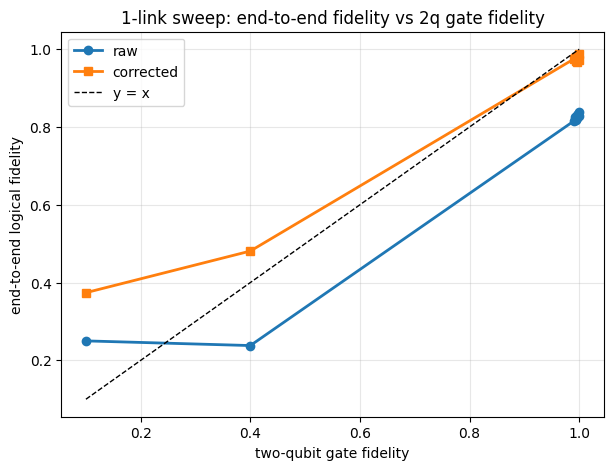

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(summary_df["twoq"], summary_df["raw"], marker="o", linewidth=2, label="raw")
ax.plot(summary_df["twoq"], summary_df["corrected"], marker="s", linewidth=2, label="corrected")

lo = min(
    summary_df["twoq"].min(),
    summary_df["raw"].min(),
    summary_df["corrected"].min(),
)
ax.plot([lo, 1.0], [lo, 1.0], "k--", linewidth=1, label="y = x")

ax.set_xlabel("two-qubit gate fidelity")
ax.set_ylabel("end-to-end logical fidelity")
ax.set_title("1-link sweep: end-to-end fidelity vs 2q gate fidelity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [18]:
out_path = Path("/Users/patange/Documents/Argonne/QEC/plot_pngs") / "main_test_twoq_sweep_1link_from_logs.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
out_path


PosixPath('/Users/patange/Documents/Argonne/QEC/plot_pngs/main_test_twoq_sweep_1link_from_logs.png')